# Notions d'overfitting vs. underfitting

### Notre projet du TP1 (reprise)

In [1]:
# Nous avons organisé nos traitements sous forme de fonctions
# pour pouvoir les réutiliser plus tard

# Fonction pour netttoyer les données
def clean_data(data):
    # Supprime les lignes avec des valeurs manquantes dans la colonne SalePrice
    data.dropna(axis=0, subset=["SalePrice"], inplace=True)
    return data

# Fonction pour diviser les données en données d'entrainement et de validation
def split_data(data, feature_names, target_name):
    # Sélectionne la variable cible que tu veux prédire
    y = data.SalePrice
    # Sélectionne les données correspondant aux variables prédictives
    X = home_data[feature_names]
    # Divise les données en données d'entrainement et de validation
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.5, random_state=42)
    return X_train, X_val, y_train, y_val

# fonction pour entrainer le modèle et evaluer les performances
def score_dataset(X_train, X_val, y_train, y_val):
    model = DecisionTreeRegressor(random_state=42)
    model.fit(X_train, y_train)
    predictions = model.predict(X_val)
    return mean_absolute_error(predictions, y_val)

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error

# Charger les données
iowa_file_path = 'data/iowa_data.csv'
home_data = pd.read_csv(iowa_file_path)
# Nettoyer les données
home_data = clean_data(home_data)
# Sélectionner les variables prédictives et la variable cible
feature_names = ['LotArea', 'YearBuilt', '1stFlrSF', '2ndFlrSF', 'FullBath', 'BedroomAbvGr', 'TotRmsAbvGrd']
target_name = 'SalePrice'
# Diviser les données en données d'entrainement et de validation
X_train, X_val, y_train, y_val = split_data(home_data, feature_names, target_name)

In [3]:
# Evaluer la performance du modèle
val_mae = score_dataset(X_train, X_val, y_train, y_val)
print("Error du modèle: ", val_mae)

Error du modèle:  30435.61506849315


### Faisons évoluer la précision de notre modèle d'apprentissage

Modifiez la fonction `score_dataset` pour qu'elle renvoie l'erreur de prédiciton sur les données de validation PUIS sur les données d'entraînement. Interpétez la différence constatée entre ces deux mesures d'erreur pour le modèle d'apprentissage. 

In [4]:
# fonction pour entrainer le modèle et evaluer les performances
def score_dataset(X_train, X_val, y_train, y_val):
    model = DecisionTreeRegressor(random_state=42)
    model.fit(X_train, y_train)
    predictions1 = model.predict(X_val)
    predictions2 = model.predict(X_train)
    return [mean_absolute_error(predictions1, y_val), mean_absolute_error(predictions2, y_train)]

In [5]:
# Evaluer la performance du modèle
val_mae = score_dataset(X_train, X_val, y_train, y_val)
print("Error du modèle: ", val_mae)

Error du modèle:  [np.float64(30435.61506849315), np.float64(18.21917808219178)]


Améliorez encore la fonction `score_dataset` afin qu'elle prenne en entrée le paramètre `max_depth` pour le modèle DecisionTreeRegressor.  

In [6]:
# fonction pour entrainer le modèle et evaluer les performances
def score_dataset(X_train, X_val, y_train, y_val, max_depth=None):
    model = DecisionTreeRegressor(random_state=42, max_depth=max_depth)
    model.fit(X_train, y_train)
    predictions1 = model.predict(X_val)
    predictions2 = model.predict(X_train)
    return [mean_absolute_error(predictions1, y_val), mean_absolute_error(predictions2, y_train)]

Tracez les courbes d'erreurs en fonction de la profondeur de l'arbre. Comparez le résultat obtenu avec la théorie (cours 1 : overffiting vs. underfitting).

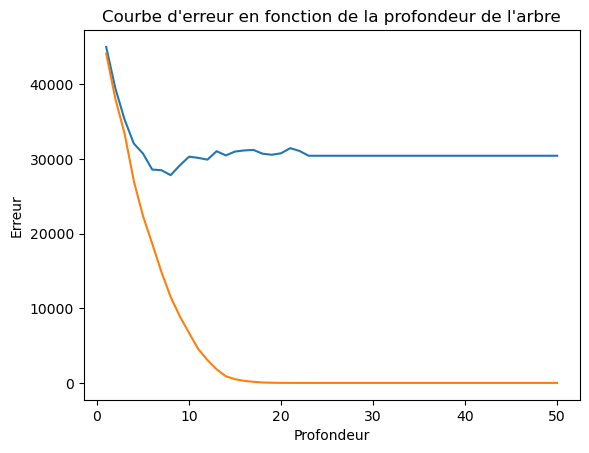

In [7]:
import matplotlib.pyplot as plt

# générer les données puis tracer les courbes
x, y1, y2 = [], [], []
for i in range(1, 51):
    x.append(i)
    val_mae = score_dataset(X_train, X_val, y_train, y_val, i)
    y1.append(val_mae[0])
    y2.append(val_mae[1])

plt.plot(x, y1)
plt.plot(x, y2)
plt.xlabel("Profondeur")
plt.ylabel("Erreur")
plt.title("Courbe d'erreur en fonction de la profondeur de l'arbre")
plt.show()

### Visualiser directement l'ajustement de l'arbre aux données

Pour "voir" concrètement l'under- et l'overfitting, entraînons un arbre de régression sur une seule variable explicative (par exemple `1stFlrSF`) et traçons le nuage de points réels ainsi que la fonction en escalier prédite par l'arbre.

Commençons par écrire une fonction qui affiche un arbre **déjà entraîné** (on sépare l'entraînement de l'affichage).

In [8]:
import numpy as np

# Fonction qui affiche l'ajustement d'un arbre déjà entraîné
# X est supposé réduit à une seule variable
def plot_tree_prediction(tree, X, y, title=None):
    feature = X.columns[0]

    # Grille de valeurs pour tracer la fonction en escalier prédite par l'arbre
    x_grid = pd.DataFrame(
        np.linspace(X[feature].min(), X[feature].max(), 1000),
        columns=[feature]
    )

    ax = plt.gca()
    ax.scatter(X[feature], y, s=10, alpha=0.3, label="données d'entrainement")
    ax.plot(x_grid[feature], tree.predict(x_grid), color='red', linewidth=2, label="prédiction de l'arbre")
    ax.set_xlabel(feature)
    subtitle = f"profondeur = {tree.get_depth()}"
    ax.set_title(f"{title}\n{subtitle}" if title else subtitle)
    ax.legend()

Entraîner un arbre de regression de profondeur 3 sur `X_train` restreint à une seule dimension (ex. la surface du 1er étage de la maison `1stFlrSF`). Puis visualisez-le.

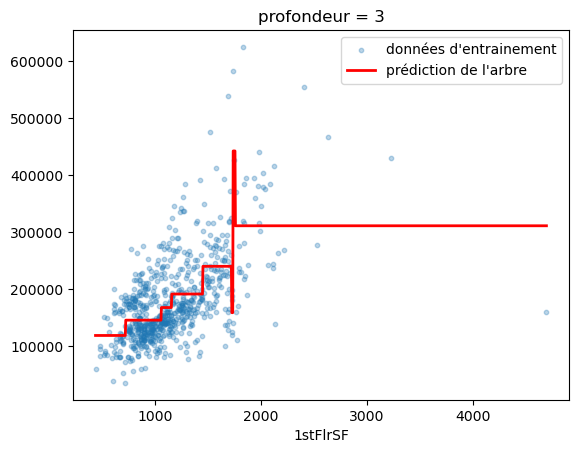

In [9]:
# entraînement de l'arbre et visualisation
X_train_id = X_train[["1stFlrSF"]]
model = DecisionTreeRegressor(random_state=42, max_depth=3)
model.fit(X_train_id, y_train)

plot_tree_prediction(model, X_train_id, y_train)

Faites à présent évoluer la profondeur de l'arbre appris afin de visualiser la complexité du modèle entraîné. Faites le lien avec la courbe d'overfitting constuite précédemment.